In [1]:
from transformers import AutoImageProcessor, DetrForObjectDetection
import torch
from PIL import Image
import requests

c:\Users\natha\Documents\Git\5th-year-polytech\transformers\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = "https://www.maisondelapresse.com/media/wysiwyg/one_piece.jpg"
image = Image.open(requests.get(url, stream=True).raw)

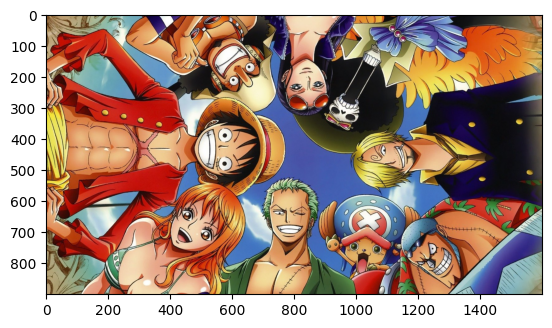

In [3]:
import matplotlib.pyplot as plt
plt.imshow(image)

In [4]:
image_processor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
c:\Users\natha\Documents\Git\5th-year-polytech\transformers\env\Lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\natha\Documents\Git\5th-year-polytech\transformers\env\Lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a 

In [5]:
inputs = image_processor(images=image, return_tensors="pt")
outputs = model(**inputs)

In [6]:
target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]

In [7]:
for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

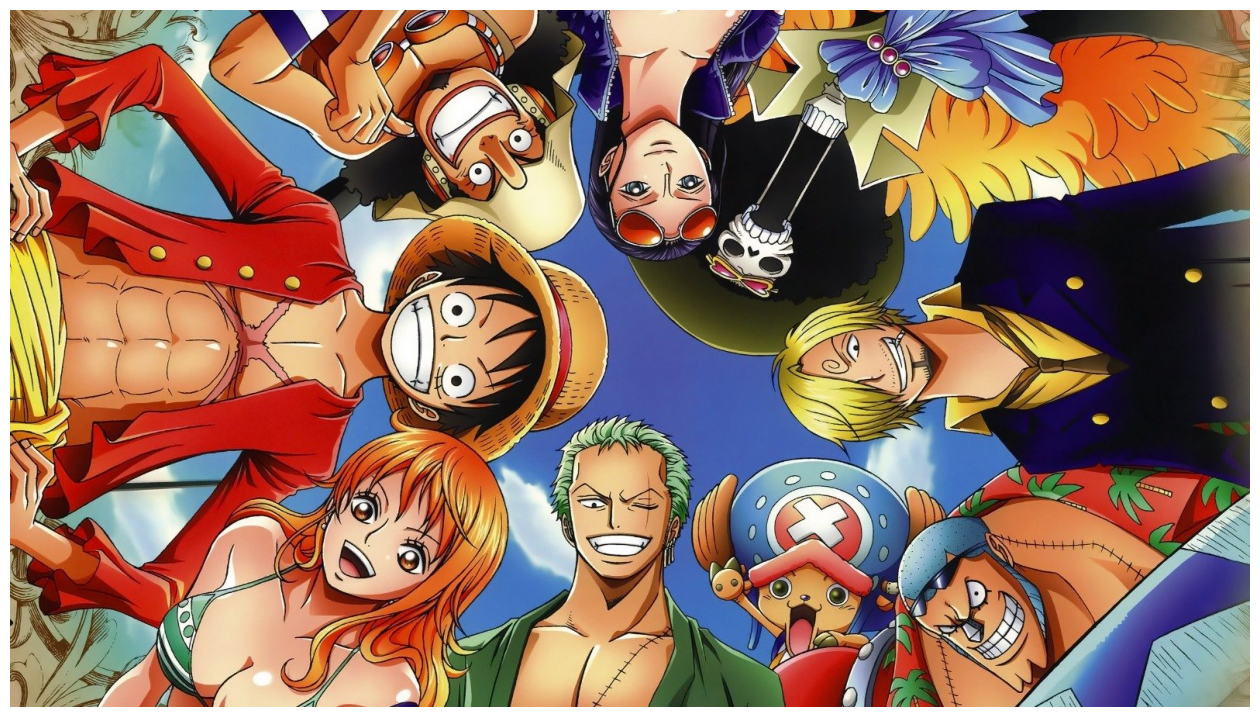

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

img_np = np.asarray(image.convert("RGB"))
fig, ax = plt.subplots(1, figsize=(16, 10))
ax.imshow(img_np)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    x0, y0, x1, y1 = map(int, box.tolist())
    x0, y0 = max(0, x0), max(0, y0)
    x1 = min(img_np.shape[1], x1)
    y1 = min(img_np.shape[0], y1)
    if x1 <= x0 or y1 <= y0:
        continue

    region = img_np[y0:y1, x0:x1]
    if region.size:
        mean_col = region.reshape(-1, 3).mean(axis=0)
    else:
        mean_col = np.array([255, 0, 0])
    edge_color = tuple((mean_col / 255.0).tolist())

    # choose text color for contrast
    luminance = 0.299 * mean_col[0] + 0.587 * mean_col[1] + 0.114 * mean_col[2]
    text_color = "white" if luminance < 128 else "black"

    rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                             linewidth=2, edgecolor=edge_color, facecolor="none")
    ax.add_patch(rect)

    label_name = model.config.id2label[label.item()]
    ax.text(x0, max(0, y0 - 8), f"{label_name} {score.item():.2f}",
            color=text_color, fontsize=10, weight="bold",
            bbox=dict(facecolor=edge_color, alpha=0.6, pad=1, edgecolor="none"))

ax.axis("off")
plt.show()